# 01 — Chỉ số ENSO (ONI)

Luồng A2 — [PHASE-1-CHECKLIST.md §A2](../../PHASE-1-CHECKLIST.md). Nguồn công khai NOAA CPC, không cần đăng ký. Nhẹ nhất trong Luồng A — chạy xong trong vài giây.

In [1]:
import sys
from pathlib import Path

_root = Path.cwd()
if not (_root / "app").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
print("project root:", _root)

project root: d:\Cuộc thi\DengueSense\ai-service


In [2]:
from app.data.ingest_oni import load_oni_monthly

oni = load_oni_monthly()
print(f"{len(oni)} dòng, phủ {oni['year'].min()}-{oni['year'].max()}")
oni.tail()

919 dòng, phủ 1950-2026


,year,month,oni
914,2026,3,0.11
915,2026,4,0.46
916,2026,5,0.95
917,2026,6,1.39
918,2026,7,1.80


## Sanity check trực quan

El Niño (ONI ≥ 0.5, thường liên quan dịch SXH tăng ở VN) tô đỏ, La Niña (ONI ≤ -0.5) tô xanh. Nhìn để nhận ra các đợt El Niño lớn đã biết (1997-98, 2015-16, 2023-24) — nếu không thấy đúng vị trí thì khả năng cao mapping SEAS→month bị lệch.

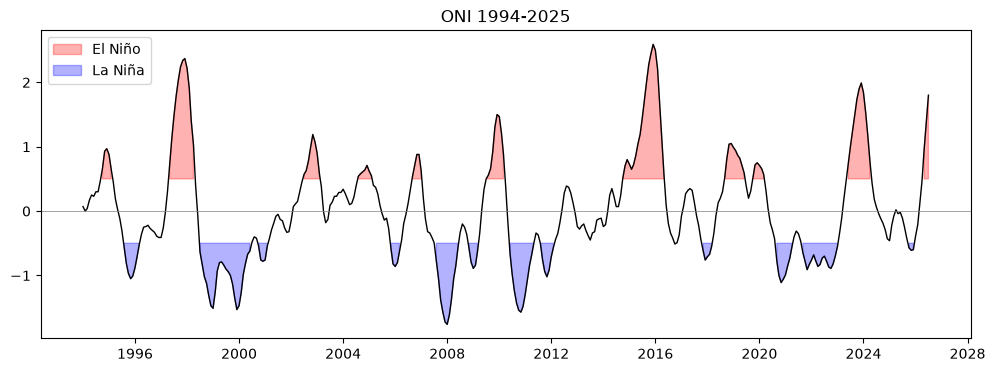

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

oni_recent = oni[oni['year'] >= 1994].copy()
oni_recent['date'] = pd.to_datetime(
    {'year': oni_recent.year, 'month': oni_recent.month, 'day': 1}
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(oni_recent['date'], oni_recent['oni'], color='black', linewidth=1)
ax.axhline(0, color='gray', linewidth=0.5)
ax.fill_between(oni_recent['date'], oni_recent['oni'], 0.5,
                 where=(oni_recent['oni'] >= 0.5), color='red', alpha=0.3, label='El Niño')
ax.fill_between(oni_recent['date'], oni_recent['oni'], -0.5,
                 where=(oni_recent['oni'] <= -0.5), color='blue', alpha=0.3, label='La Niña')
ax.set_title('ONI 1994-2025')
ax.legend()
plt.show()

## Lưu ra `data/interim/`

In [4]:
interim_dir = _root / 'data' / 'interim'
interim_dir.mkdir(parents=True, exist_ok=True)
out_path = interim_dir / 'oni_monthly.parquet'
oni[['year', 'month', 'oni']].to_parquet(out_path, index=False)
print(f'Đã lưu {len(oni)} dòng vào {out_path}')

Đã lưu 919 dòng vào d:\Cuộc thi\DengueSense\ai-service\data\interim\oni_monthly.parquet
